# D13 · Voxel families, clusters, and TFCE are different targets

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD05](../../curriculum/papers/design.md#pd05).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Does the reported error rate concern voxels, clusters, or another family of decisions?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

Testing many locations creates many opportunities for a false positive. Family-wise error control bounds the probability of at least one false rejection in a specified family. False-discovery-rate control targets an expected false-discovery proportion. Neither says that a positive region is biologically important. The family must include the searches actually made: locations, contrasts, outcomes, or other choices may all matter.

A maximum-statistic permutation procedure forms the largest statistic across the family in each allowed null relabelling. Comparing each observed location with that maximum distribution accounts for the family under the procedure's assumptions. A cluster procedure instead uses a spatial aggregation such as cluster size or mass after a chosen cluster-forming threshold. A significant cluster does not imply that every voxel within it is individually significant or identify an exact biological boundary.

Threshold-free cluster enhancement, TFCE, accumulates support from a location's height and the extent of connected support across thresholds. It avoids choosing a single cluster-forming threshold, but retains choices about topology, exponents, integration, sidedness, and null calibration. The enhanced value is not a p value. Proper inference needs an appropriate null distribution, often a permutation distribution of the maximum enhanced score.

Our small implementation is deliberately one-dimensional and one-sided. It uses nearest-neighbor connectivity, E=.5 and H=2, and a discrete integration step of .25. It is not a substitute for a tested 3D imaging implementation. We enumerate sign flips for eight independent symmetric subject-level maps, recompute their t statistics, apply the identical enhancement, and retain each maximum. Using the same transformation for observed and null maps is essential. Coarse integration is part of this toy statistic and influences numerical values; it does not justify comparing scores from different settings. Real spatial inference also needs a valid analysis mask, smoothness considerations, registration quality, and a defensible exchangeability scheme.

An isolated peak and a neighboring pair can have the same height but different enhanced scores. Scores are not probabilities.

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def tfce_1d(values,dh=.25):
    result=np.zeros_like(values,dtype=float)
    for h in np.arange(dh,values.max()+dh/2,dh):
        labels,count=ndimage.label(values>=h)
        sizes=np.bincount(labels);sizes[0]=0
        result += np.sqrt(sizes[labels])*h**2*dh
    return result
isolated=np.array([0.,2.,0.,0.,0.])
paired=np.array([0.,2.,2.,0.,0.])
assert tfce_1d(paired)[1]>tfce_1d(isolated)[1]
assert np.all(tfce_1d(np.zeros(5))==0)
print('Isolated / supported score:',tfce_1d(isolated)[1],tfce_1d(paired)[1])

Isolated / supported score: 3.1875 4.5078057300642405


Calibrate the entire transformation under every allowed subject sign flip. This toy performs positive, one-sided family-wise inference.

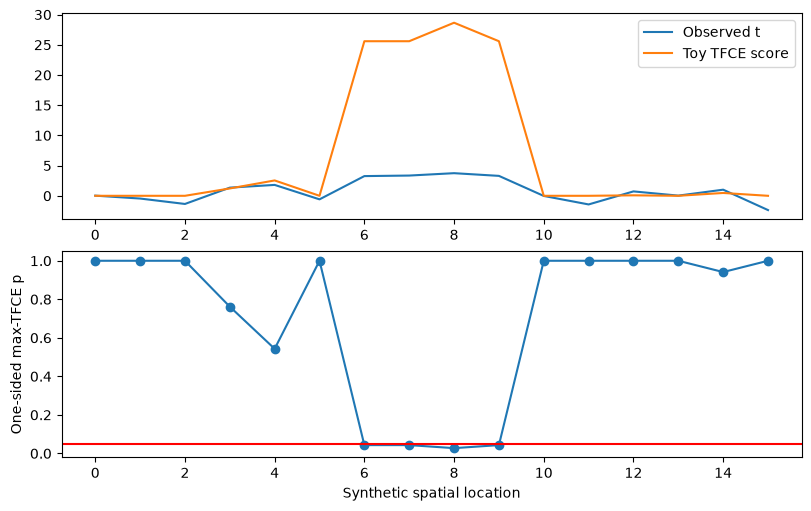

Corrected p values: [1.         1.         1.         0.76171875 0.54296875 1.
 0.04296875 0.04296875 0.02734375 0.04296875 1.         1.
 1.         1.         0.94140625 1.        ]


In [2]:
rng=np.random.default_rng(213)
maps=rng.normal(size=(8,16));maps[:,6:10]+=1.2

def t_map(data):
    return data.mean(axis=0)/(data.std(axis=0,ddof=1)/np.sqrt(data.shape[0]))
observed=t_map(maps);enhanced=tfce_1d(observed)
patterns=np.array(list(itertools.product([-1,1],repeat=8)))
max_null=np.array([tfce_1d(t_map(maps*s[:,None])).max() for s in patterns])
p_fwe=np.mean(max_null[:,None]>=enhanced[None,:]-1e-12,axis=0)
assert np.all((p_fwe>=1/256)&(p_fwe<=1))
assert np.all(p_fwe[enhanced==0]==1)
fig,ax=plt.subplots(2,1,figsize=(8,5),constrained_layout=True)
ax[0].plot(observed,label='Observed t');ax[0].plot(enhanced,label='Toy TFCE score');ax[0].legend()
ax[1].plot(p_fwe,'o-');ax[1].axhline(.05,color='red')
ax[1].set(xlabel='Synthetic spatial location',ylabel='One-sided max-TFCE p')
plt.show();print('Corrected p values:',p_fwe)

## Supervise the AI, then transfer the idea

**AI prompt:** “Distinguish voxelwise FWE, FDR, cluster-level inference, and TFCE enhancement. Explain why scores above one are normal but p values above one are impossible. Audit the one-sidedness and subject-level sign flips. Do not call this 1D demonstration production-ready.”

**Deliberate mistake:** threshold enhanced values at .05 as if they were p values. Repair the workflow by constructing the calibrated maximum distribution. Then explain why changing connectivity only for the observed map invalidates the comparison. For real work, choose a validated package, predefine contrasts and masks, record permutation count and topology, and interpret the correct spatial inferential unit. Deliver a result caption explicitly limiting this toy to eight independent subject maps and one-sided testing. Cluster or TFCE significance does not identify an exact neuronal mechanism or remove the need for effect estimates.

## Answer key — read after your own explanation

The neighboring pair gains extent support, hence greater TFCE despite equal peak height. Calibration uses 256 sign patterns; including the observed pattern prevents p=0. Locations with zero positive enhancement have p=1. A max-null comparison addresses the family of 16 locations under the stated sign-flip assumptions. The code does not implement two-sided TFCE, 3D connectivity, or parametric random-field cluster inference; those are deliberate transfer gaps, not silently approximated features.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [DartBrains Thresholding Group Analyses](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/Thresholding_Group_Analyses.ipynb); [FSL randomise, TFCE and output interpretation](https://fsl.fmrib.ox.ac.uk/fsl/docs/statistics/randomise.html); [Berkeley syllabus, inference on maps](https://github.com/bic-berkeley/psych-214-fall-2016/blob/ec44652addc92091183456fa04fcd41dca0e172e/syllabus.rst). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD05](../../curriculum/papers/design.md#pd05) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
